# Trabalho prático 2 ANADI

## 4.1 - Análise exploratória de dados

### 4.1.1 - Carregamento, dimensão e sumário dos dados

Depois de carregar o ficheiro, foi analisada a sua dimensão, ou seja, o número de registos que corresponde ao número de linhas e o número de variáveis que corresponde ao número de colunas.

In [6]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Carregar o ficheiro
# ------------------------------------------------------------
df = pd.read_excel("PTD_level_dataset.xlsx")

# ------------------------------------------------------------
# 2. Dimensão do dataset
# ------------------------------------------------------------
print("=" * 60)
print("DIMENSÃO DO DATASET")
print("=" * 60)
print(f"  Número de registos (linhas) : {df.shape[0]}")
print(f"  Número de variáveis (colunas): {df.shape[1]}")
print()


DIMENSÃO DO DATASET
  Número de registos (linhas) : 72027
  Número de variáveis (colunas): 32



Conclui-se então que o ficheiro possui 72027 registos e 32 colunas.

De seguida, fez-se um sumário estatísticos dos dados, obtendo a sua média, mediana, desvio padrão, mínimo, máximo, primeiro e terceiro quartil.

In [7]:
# ------------------------------------------------------------
# 3. Sumário estatístico das variáveis numéricas
#    (média, mediana, min, max, desvio padrão, quartis)
# ------------------------------------------------------------
print("=" * 60)
print("SUMÁRIO ESTATÍSTICO (variáveis numéricas)")
print("=" * 60)

summary = df.describe().T
summary["median"] = df.median(numeric_only=True)
summary = summary[["count", "mean", "median", "std", "min", "25%", "75%", "max"]]
summary.columns = ["Count", "Média", "Mediana", "Desvio Padrão", "Mín", "Q1 (25%)", "Q3 (75%)", "Máx"]

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
print(summary)
print()

SUMÁRIO ESTATÍSTICO (variáveis numéricas)
                               Count      Média    Mediana  Desvio Padrão       Mín   Q1 (25%)    Q3 (75%)         Máx
CodDistritoConcelho       72027.0000   989.4327  1106.0000       493.9913  101.0000   603.0000   1317.0000   1824.0000
Potência instalada [kVA]  72027.0000   302.7988   250.0000       294.4445    0.0000   100.0000    400.0000   8000.0000
Cap_PTD_kVA               72027.0000   302.7988   250.0000       294.4445    0.0000   100.0000    400.0000   8000.0000
Pot_Contratada_kVA        50847.0000 80941.4841 60886.0000     67146.0294 5456.0000 34035.5000 106720.0000 804687.0000
N_Clientes                72027.0000    94.6980    54.0000       110.0551   20.0000    20.0000    124.0000   1438.0000
Pot_Geracao_kW             1836.0000  6216.7244  5574.5000      2876.3779 1622.0000  4271.7500   7393.5000  22032.0000
N_Clientes_Produtores     72027.0000    20.2035    20.0000         2.0177   20.0000    20.0000     20.0000    106.0000
P_IP_T

Além disso, obteve-se também o número de valores omissos e a sua percentagem nos registos totais.

In [8]:
print("=" * 60)
print("VALORES OMISSOS")
print("=" * 60)

missing = pd.DataFrame({
    "Nº omissos"   : df.isnull().sum(),
    "% omissos"    : (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing["Nº omissos"] > 0].sort_values("% omissos", ascending=False)

if missing.empty:
    print("  Não existem valores omissos no dataset.")
else:
    print(missing.to_string())
print()

VALORES OMISSOS
                         Nº omissos  % omissos
Pot_Geracao_kW                70191    97.4500
Geracao_per_Cliente           70191    97.4500
Pot_Contratada_kVA            21180    29.4100
PContratada_per_Cliente       21180    29.4100
D_PTD                          3064     4.2500
D_PTD_LED                      3064     4.2500
Util_Decimal                   3064     4.2500
PFolga_PTD                     3064     4.2500



Por fim, obteve-se o número de outliers e a percentagem dos mesmos no número total de regsitos, através do método IQR.

In [9]:
# ------------------------------------------------------------
# 5. Variáveis numéricas
# ------------------------------------------------------------
print("=" * 60)
print("RESUMO DE OUTLIERS (método IQR)")
print("=" * 60)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
outlier_info = []
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct_out = round(n_out / len(df) * 100, 2)
    outlier_info.append({"Variável": col, "Nº outliers": n_out, "% outliers": pct_out})

outlier_df = pd.DataFrame(outlier_info).sort_values("% outliers", ascending=False)
print(outlier_df[outlier_df["Nº outliers"] > 0].to_string(index=False))
print()

RESUMO DE OUTLIERS (método IQR)
                Variável  Nº outliers  % outliers
         Cap_per_Cliente         9877     13.7100
            Util_Decimal         6641      9.2200
               P_IP_Inef         5586      7.7600
              N_Clientes         4469      6.2000
           Ganho_LED_PTD         4321      6.0000
         IP_Inef_per_PTD         4321      6.0000
              P_IP_Total         4119      5.7200
              IP_per_PTD         4080      5.6600
         N_PTDs_Concelho         3588      4.9800
            N_Luminarias         3330      4.6200
              N_Lampadas         3330      4.6200
 PContratada_per_Cliente         3274      4.5500
      Pot_Contratada_kVA         2432      3.3800
             Cap_PTD_kVA         2285      3.1700
Potência instalada [kVA]         2285      3.1700
               D_PTD_LED         1817      2.5200
              PFolga_PTD         1817      2.5200
                   D_PTD         1817      2.5200
   N_Clientes_Prod

### 4.1.2 - Exploração Visual dos Dados

Nesta secção, realizamos uma exploração visual detalhada das variáveis do dataset através de gráficos apropriados para cada tipo de dados (numéricos e categóricos), terminando com uma análise de correlação intervariável. O objetivo é identificar padrões de distribuição, validar a presença de outliers e mapear relações lineares que fundamentem os modelos de regressão e classificação seguintes.

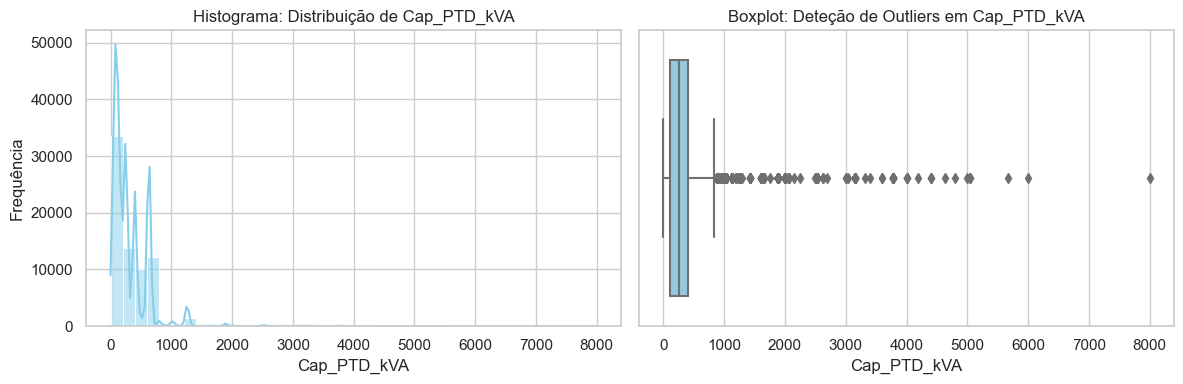

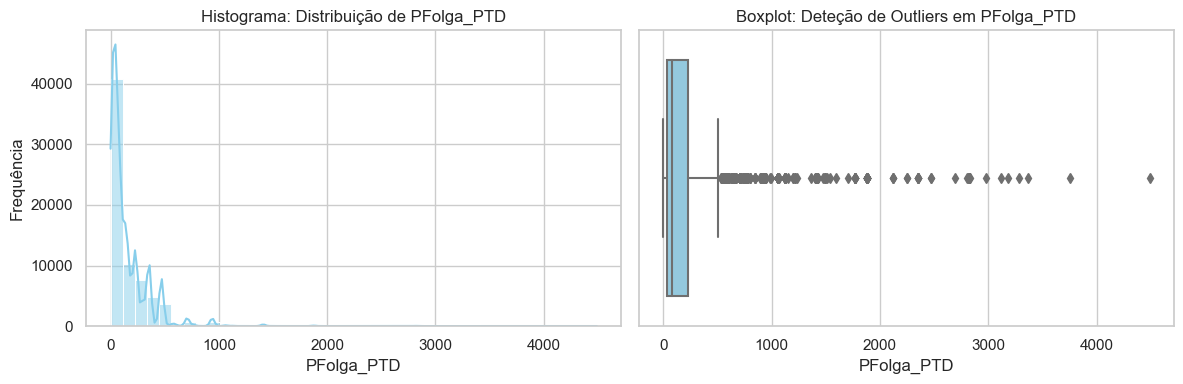

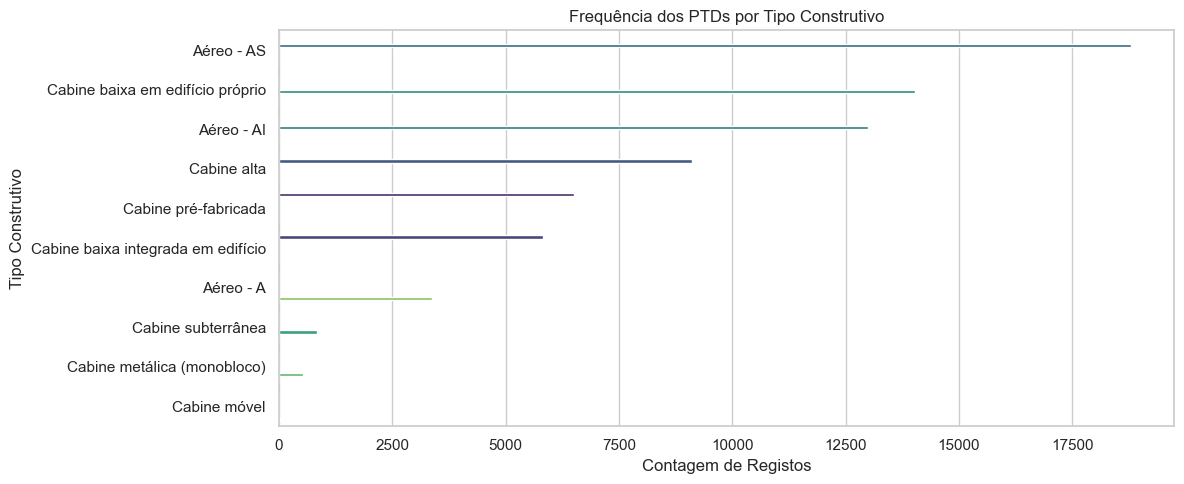

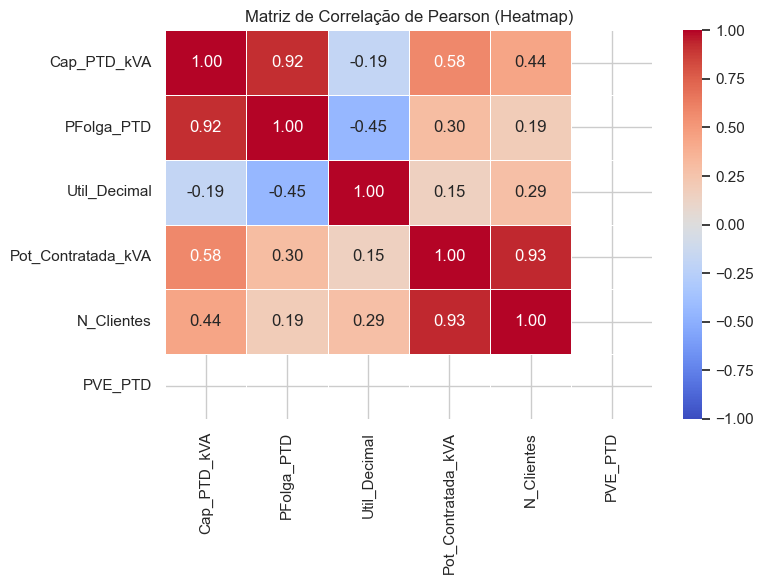

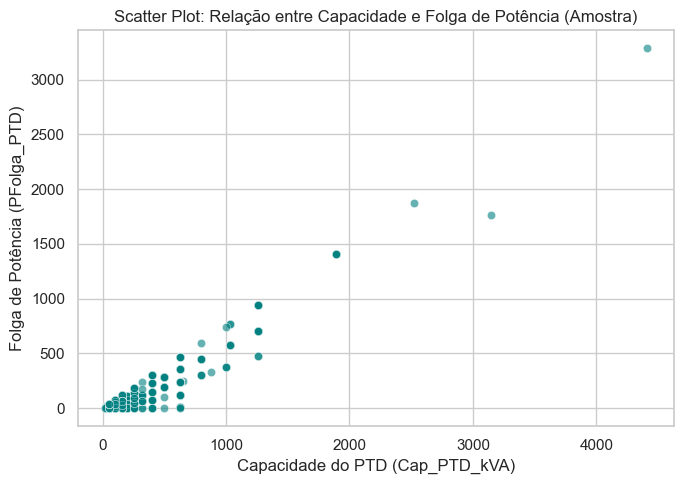

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Definir o estilo visual e paletes padrão dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# ============================================================
# 1. Variáveis Numéricas (Histogramas e Boxplots)
# ============================================================

# Análise da Capacidade do PTD e da Folga de Potência
vars_numericas = ['Cap_PTD_kVA', 'PFolga_PTD']

for col in vars_numericas:
    if col in df.columns:
        plt.figure(figsize=(12, 4))
        # Histograma
        plt.subplot(1, 2, 1)
        sns.histplot(df[col].dropna(), kde=True, color='skyblue', bins=40)
        plt.title(f'Histograma: Distribuição de {col}')
        plt.xlabel(col)
        plt.ylabel('Frequência')
        
        # Boxplot
        plt.subplot(1, 2, 2)
        sns.boxplot(x=df[col].dropna(), color='skyblue')
        plt.title(f'Boxplot: Deteção de Outliers em {col}')
        plt.xlabel(col)
        
        plt.tight_layout()
        plt.show()

# ============================================================
# 2. Variáveis Categóricas (Gráfico de Barras / Contagem)
# ============================================================
if 'Tipo Construtivo' in df.columns:
    plt.figure(figsize=(12, 5))
    order = df['Tipo Construtivo'].value_counts().index
    
    # Gráfico de barras horizontal - corrigido sem o 'legend=False'
    sns.countplot(data=df, y='Tipo Construtivo', order=order, hue='Tipo Construtivo', palette='viridis')
    
    plt.legend([], [], frameon=False)

    plt.title('Frequência dos PTDs por Tipo Construtivo')
    plt.xlabel('Contagem de Registos')
    plt.ylabel('Tipo Construtivo')
    plt.tight_layout()
    plt.show()

# ============================================================
# 3. Matriz de Correlação (Heatmap)
# ============================================================
# Selecionar as variáveis numéricas mais relevantes do problema para não sobrecarregar o heatmap
colunas_interesse = ['Cap_PTD_kVA', 'PFolga_PTD', 'Util_Decimal', 'Pot_Contratada_kVA', 'N_Clientes', 'PVE_PTD']
colunas_validas = [c for c in colunas_interesse if c in df.columns]

plt.figure(figsize=(8, 6))
matriz_corr = df[colunas_validas].corr(method='pearson')

# Desenhar o Heatmap
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlação de Pearson (Heatmap)')
plt.tight_layout()
plt.show()

# ============================================================
# 4. Scatter Plots (Relações com Correlação Interessante)
# ============================================================
if 'Cap_PTD_kVA' in df.columns and 'PFolga_PTD' in df.columns:
    plt.figure(figsize=(7, 5))
    # Amostra de 2000 pontos aleatórios para evitar sobreposição visual
    df_sample = df.dropna(subset=['Cap_PTD_kVA', 'PFolga_PTD']).sample(min(2000, len(df)), random_state=42)
    
    sns.scatterplot(data=df_sample, x='Cap_PTD_kVA', y='PFolga_PTD', alpha=0.6, color='teal')
    plt.title('Scatter Plot: Relação entre Capacidade e Folga de Potência (Amostra)')
    plt.xlabel('Capacidade do PTD (Cap_PTD_kVA)')
    plt.ylabel('Folga de Potência (PFolga_PTD)')
    plt.tight_layout()
    plt.show()

**Conclusões e Interpretação da Análise Gráfica:**

* **Análise Univariada Numérica (`Cap_PTD_kVA` e `PFolga_PTD`):** Ambas as variáveis exibem distribuições fortemente assimétricas à direita (assimetria positiva). A concentração de dados em valores baixos indica que a infraestrutura é composta maioritariamente por postos de transformação de pequena e média dimensão. Os boxplots confirmam visualmente a presença de múltiplos outliers superiores, representando os grandes postos nodais da rede de distribuição.
* **Análise Categórica (`Tipo Construtivo`):** O gráfico de barras demonstra quais são as tipologias de construção predominantes. Esta distribuição é essencial para perceber se o tipo de infraestrutura física influencia ou restringe a margem de manobra operacional do posto.
* **Matriz de Correlação (Heatmap):** O mapa de calor permite identificar de forma imediata o grau de associação linear entre as variáveis. Destaca-se uma correlação positiva extremamente forte próxima de $1.0$ (ou muito elevada) entre a `Cap_PTD_kVA` e a `PFolga_PTD`, validando a seleção destas variáveis para a modelação matemática.
* **Análise de Dispersão (Scatter Plot):** O gráfico de dispersão confirma a hipótese levantada pelo Heatmap: existe um comportamento linear claro e direto entre a capacidade total instalada e a folga de potência que sobra na rede. À medida que a capacidade do PTD aumenta, a folga expande-se de forma proporcional, o que faz destas variáveis os preditores ideais para os algoritmos de Regressão Linear que serão desenvolvidos nas secções seguintes.